## Chronic Kidney Disease

The main objective of this project is to develop a robust and accurate predective model for use in diagnosis based on specific markers or features.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

## Member 1 (Celica) - Data Cleaning

In [ ]:
# first let's import the dataset and explore it

df = pd.read_csv('chronic_kindey_disease.csv', na_values='?') # missing values are denoted by ? - let's replace them with pandas NaN values
df.head()

In [ ]:
# to understand better the columns, let's look at the info file of the dataset

with open("chronic_kidney_disease_info.txt", "r") as f:
    content = f.read()

print(content)

We see there are 25 columns and 400 rows. Out of the 25 columns, 11 are numeric and 14 are nominal. Out of the 400 rows, there are 250 cases of chronic kindey disease and 150 cases of not CKD. The "patient identifier" is their age (even though this is not a unique value), and then we have the results of several lab tests of this patient, and then in the 'status' column whether the patient has CKD or not.

In [ ]:
# check if there are any duplicates

df.duplicated().sum()

# no duplicates, so no need to drop anything

In [ ]:
# we will also replace yes by 1 and no by 0, and present by 1 and notpresent by 0, etc.

df['rbc'] = df['rbc'].replace({'normal':1, 'abnormal':0})
df['pc'] = df['pc'].replace({'normal':1, 'abnormal':0})
df['pcc'] = df['pcc'].replace({'notpresent':0, 'present':1})
df['ba'] = df['ba'].replace({'notpresent':0, 'present':1})

df['htn'] = df['htn'].replace({'no':0, 'yes':1})
df['dm'] = df['dm'].replace({'\tno':'no'})
df['dm'] = df['dm'].replace({'no':0, 'yes':1})
df['cad'] = df['cad'].replace({'no':0, 'yes':1})
df['appet'] = df['appet'].replace({'poor':0, 'good':1})
df['pe'] = df['pe'].replace({'no':0, 'yes':1})
df['ane'] = df['ane'].replace({'no':0, 'yes':1})

df['status'] = df['status'].replace({'ckd\t':'ckd'})
df['status'] = df['status'].replace({'notckd':0, 'ckd':1})

df.head()

In [ ]:
# we will also create dummies for nominal columns with more than 2 categories (which we previously encoded to 0 and 1)
# this for their later use in ML models

columns = ["sg", "al", "su"]

for col in columns:
    df = pd.get_dummies(df, columns=[col])

df.head()

In [ ]:
# let's look at all numeric columns individually and see if we find something peculiar

df = df.astype('float') # changing column types to integer
df.describe()

In [ ]:
# now we look at the number of missing values per column
# we see some columns with even more than 25% missing data

df.isna().sum()

These missing values could be handled in many ways - we could remove the rows with missing values, or we could impute the values. However at this stage, we will leave them as they are, as the later approach depends on the specific features and ML model chosen.

In [ ]:
# we will now briefly look at the correlations
# to see which columns would not be useful for the ML model, due to being highly correlated with another

threshold = 0.7
corr = df.corr(numeric_only=True) # get a matrix of Pearson correlations
np.fill_diagonal(corr.values, 0) # change the 100% correlations of the column with itself to 0
mask = (corr.abs() >= threshold) # create a mask of only keeping the absolute correlations above a set threshold
cols = mask.any(axis=0) # keep the column if there's at least one other column with which the absolute correlation exceeds the threshold
filtered_corr = corr.loc[cols, cols]
filtered_corr

We note that the pairs with absolute correlations of at least 70% are the following - hemo and pcv, hemo and rbcc, hemo and status, pcv and rbcc, pcv and status, (rbcc and status,) status and al_0.0. Therefore when creating the ML model, we should be careful of multicollinearities and see if adding both the columns of the mentioned pairs really results in model imprvement, or if this decreases the accuracy.

In [ ]:
# check if data approx normal or skewed

from scipy.stats import skew, kurtosis

for col in df.columns:
    print(col)
    skewness = skew(df[col], nan_policy='omit')
    kurt = kurtosis(df[col], nan_policy='omit')
    print(skewness.round(2), kurt.round(2))

# skewness >0.5 is right-skewed, <-0.5 is left-skewed, >1 is strongly skewed
# kurt >1 is heavy tails, <-1 is light tails, 0 is normal tails

As most columns are either highly skewed or have heavy tails, it makes more sense to use the IQR method for outlier detection. Nevertheless we will try both - IQR and Z-score.

In [ ]:
# next, we are interested in if there are any outliers
# one way to do this is using the standard interquantile range on the numerical columns

def remove_outliers_iqr(df, col):
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
        
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
        
    return df_clean

In [ ]:
# (we see that all 10 detected outliers of the age column are children under the age of 9
# we will proceed to remove these observations)

df_clean_iqr = remove_outliers_iqr(df, 'age')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'bp')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'bgr')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'bu')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'sc')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'sod')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'pot')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'hemo')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'pcv')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'wbcc')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'rbcc')

# left with 145 rows out of the original 400

In [ ]:
# another way to detect outliers is to use z-scores
# let's see if this results in fewer outliers than with the IQR method

from scipy import stats
import numpy as np

def remove_outliers_z(df, col, threshold_z):
    
    z = np.abs(stats.zscore(df[col], nan_policy="omit"))
    outlier_indices = df.index[z > threshold_z]
    df_clean_z = df.drop(outlier_indices)
    print("Original DataFrame Shape:", df.shape)
    print("DataFrame Shape after Removing Outliers:", df_clean_z.shape)
        
    return df_clean_z

In [ ]:
# we will use 2 as the threshold, as this will keep approximately 95% of the data in each column

df_clean_z = remove_outliers_z(df, 'age', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'bp', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'bgr', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'bu', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'sc', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'sod', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'pot', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'hemo', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'pcv', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'wbcc', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'rbcc', 2)

We see that using the z-score outlier detection method we are left with a bigger dataset - 282 observations instead of the 145 of the IQR method. However these extra observations likely come from the z-score method not being as robust as most columns contain either highly skewed or heavy tails data.

It will be interesting to see how df, df_clean_iqr and df_clean_z compare in the next analysis and the prediction of CKD.

## Member 2 (Ema) – Exploratory Data Analysis
# Follow-up Analysis Description
In this part of the project, I continue working with two cleaned versions of the dataset produced in the Member 1 (Celica) branch after encoding, missing-value inspection, and outlier removal: an IQR-cleaned dataset (df_clean_iqr, n = 145) and a Z-score–cleaned dataset (df_clean_z, n = 282). My work begins after data cleaning and focuses on exploratory data analysis (EDA).
Due to the big nature of multivariate outlier removal using the IQR method, the IQR-cleaned dataset is substantially reduced in size. Therefore, findings derived from this dataset should be interpreted as exploratory rather than definitive, and comparisons with the Z-score cleaned dataset are used to contextualize these observations.

Specifically, I implement utility functions to (1) aggregate numerical variables using group-based averaging (group_and_average), (2) generate scatterplots for selected pairs of numerical variables grouped by CKD status using a reusable visualization function, and (3) construct helper identifiers (such as a subject_id) to facilitate traceability at the individual-record level. The generated subject_id is used only for identification purposes and is excluded from aggregation and modeling steps.

Appropriate, analyses are performed on copied versions of the cleaned datasets to preserve the original cleaning results. All visualizations use a consistent Seaborn color palette (`YlGnBu`) to improve clarity and comparability across plots.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
cleaned_dataframe_iqr = df_clean_iqr.copy()

cleaned_dataframe_iqr.shape

In [ ]:
cleaned_dataframe_z = df_clean_z.copy()

cleaned_dataframe_z.shape

**(1) aggregate numerical variables using group-based averaging - `group_and_average`**

The original dataset contains 11 numerical (continuous) variables and 14 categorical (nominal) variables. The target variable is status, indicating whether a patient has chronic kidney disease (CKD) or not. During preprocessing, the variables specific gravity (sg), albumin (al), and sugar (su) —were transformed into dummy variables using one-hot encoding for later use in machine-learning models. As a result, these variables no longer exist as single numerical columns and are therefore excluded from numerical aggregation in the EDA stage. Instead, they are treated as categorical features and considered only in categorical analysis.

In [ ]:
# numeric columns (8)
numeric_vars = [
    'age', 'bp','bgr', 'bu','sc','sod','pot','hemo'
]
#categogorical columns (17)
categorical_vars = [
    'rbc', 'pc', 'pcc', 'ba', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad','appet', 'pe', 'ane','status', 'sg','al','su'
]


**Specifying the aggregation function**

In [ ]:
# function for the use of `group_and_average`
def group_and_average(df, group_col, numeric_cols):
    aggregated_df = df.groupby(group_col)[numeric_cols].mean().reset_index()
    return aggregated_df

**IQR-cleaned dataset**

In [ ]:
aggregated_df_iqr = group_and_average(
    df=df_clean_iqr,
    group_col='status',
    numeric_cols=numeric_vars
) 

In [ ]:
cleaned_dataframe_iqr['status'].value_counts()

=== results 

After cleaning and binary encoding of the target variable (status, where 0 = non-CKD and 1 = CKD), the IQR-cleaned dataset is highly imbalanced. The majority class consists of 128 non-CKD patients, while only 17 patients are labeled as CKD, indicating a strong class imbalance that must be considered in subsequent modeling.

**Z-score cleaned dataset**

In [ ]:
aggregated_df_z = group_and_average(
    df=df_clean_z,
    group_col='status',
    numeric_cols=numeric_vars
) 

In [ ]:
cleaned_dataframe_z['status'].value_counts()

=== results

In contrast to the IQR-cleaned dataset, the Z-score–cleaned dataset shows an approximately balanced class distribution. After Z-score–based outlier removal, the dataset contains 147 non-CKD patients and 135 CKD patients, reducing concerns related to class imbalance for subsequent modeling.

The difference in class balance between the IQR- and Z-score–cleaned datasets highlights the impact of outlier removal strategy on class representation. This is particularly relevant for distance-based classifiers such as KNN, which are sensitive to class imbalance. Based on these observations, I will prioritize the Z-score–cleaned dataset and name it `cleaned_dataframe` for further analysis and modeling.

In [ ]:
cleaned_dataframe = cleaned_dataframe_z.copy()

**(2) Create scatterplot function for two variables grouped by category**

Scatterplots are generated to visualize relationships between pairs of numerical variables, grouped by CKD status. Firstly we are going to make an scatterplot function for two variables grouped by category and then we will use this function to create scatterplots for selected variable pairs. 

Since scatterplots are used to visualize the relationship in numeric variables, we will only conider those 8 numeric variables: age, bp, bgr, bu, sc, sod, pot, hemo. 
- full numeric names
- scatterplot function 
- use the function to create all pairs of scatterplots for these 8 numeric variables grouped by the target variable status (CKD vs non-CKD)
- use this function in plotting scatterplots for all pairs of numeric variables grouped by CKD status.

In [ ]:
full_numeric_names = {
    'age': 'Age (years)',
    'bp': 'Blood Pressure (mm/Hg)',
    'bgr': 'Blood Glucose Random (mgs/dl)',
    'bu': 'Blood Urea (mgs/dl)',
    'sc': 'Serum Creatinine (mgs/dl)',
    'sod': 'Sodium (mEq/L)',
    'pot': 'Potassium (mEq/L)',
    'hemo': 'Hemoglobin (gms)'
}


In [ ]:
def scatterplot_by_group(
    df,
    x_var,
    y_var,
    group_col,
    ax=None,
    name_map=None,
    show_legend=False
):
    plot_df = df.copy()

    # Map status for readability
    if group_col == 'status':
        plot_df[group_col] = plot_df[group_col].map({
            0: 'Non-CKD',
            1: 'CKD'
        })

    x_label = name_map.get(x_var, x_var) if name_map else x_var
    y_label = name_map.get(y_var, y_var) if name_map else y_var

    if ax is None:
        plt.figure(figsize=(6, 5))
        ax = plt.gca()
        standalone = True
    else:
        standalone = False

    sns.scatterplot(
        data=plot_df,
        x=x_var,
        y=y_var,
        hue=group_col,
        palette='YlGnBu',
        alpha=0.7,
        ax=ax,
        legend=show_legend
    )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(f'{y_label} vs {x_label}')

    if standalone:
        plt.tight_layout()
        plt.show()


Applying this function to all pairs of numerical variables allows us to visually assess potential differences in distributions and relationships between CKD and non-CKD patients. We are espesially interested if there is any correlation between the variables, since they can overtrain the model if correlaten occur between the features.

In [ ]:
# using only to make the combinations of all numeric variables
from itertools import combinations
import math

pairs = list(combinations(numeric_vars, 2))  # 28 pairs

n_cols = 3
n_rows = math.ceil(len(pairs) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for idx, ((x_var, y_var), ax) in enumerate(zip(pairs, axes)):
    scatterplot_by_group(
        cleaned_dataframe,
        x_var=x_var,
        y_var=y_var,
        group_col='status',
        ax=ax,
        name_map=full_numeric_names,
        show_legend=(idx == 0)  
    )


for ax in axes[len(pairs):]:
    ax.remove()


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title='CKD Status',
    loc='upper right'
)

plt.tight_layout()
plt.show()


The dataset shows that chronic kidney disease is most strongly associated with direct kidney function markers. Serum creatinine and blood urea have a clear positive correlation, especially in CKD patients. Hemoglobin shows a strong negative relationship with both creatinine and urea, indicating anemia as kidney function worsens. These three variables clearly separate CKD from non-CKD cases. Age and blood pressure show only moderate relationships and act more as risk factors than direct indicators. Blood glucose has an indirect association, suggesting a contributing but not defining role. Sodium and potassium remain relatively stable and show little meaningful correlation. Overall, kidney function and hematological markers explain the dataset far better than electrolytes or demographics.

**(3) Generate subject_id and trial columns from name and remove name**

Adding a subject_id column to uniquely identify each patient in the dataset. This is particularly useful for tracking individual patients across analyses or models. The subject_id is generated by creating a unique integer for each row in the cleaned dataframe starting form 1 to 145, with the letter `S` prefixed to indicate subject ID and it is added as a first column in the dataframe.

In [ ]:
cleaned_dataframe = cleaned_dataframe.reset_index(drop=True)

cleaned_dataframe['subject_id'] = (
    'S' + (cleaned_dataframe.index + 1).astype(str).str.zfill(2)
)
cols = ['subject_id'] + [c for c in cleaned_dataframe.columns if c != 'subject_id']
cleaned_dataframe = cleaned_dataframe[cols]
cleaned_dataframe.head(145)

- Numerical variables were aggregated by CKD status using the group and average function, resulting in the creation of an `aggregated_dataframe` 
- A reusable scatterplot function was implemented to explore relationships between numerical variables, with observations grouped by CKD status. While the function supports optional group-specific trend lines, the primary analysis focused on scatterplots without trend lines to assess overlap, correlation structure, and potential linear separability across multiple variable pairs
- Finally, a unique subject_id was generated to ensure clear identification of individual records. As the dataset does not contain trial-based or repeated-measurement data, the subject_id is included in the `cleaned_dataframe` 

# Member 3 (Clara) - Data Preprocessing: Normalization and Feature Selection

In this section, I work with the clean dataset in order to prepare it for the ML models. The main goal is to stadarize the input deatures and reduce redundancy levels among variables, which are important steps before model traning.

My tasks include separating the target variable (`status`) from the predictor features, splitting the data into training and test sets while preserving class balance, and applying Z-score normalization to the input variables. I also perfom a correlation analysis in order to identify highly correlated and retain only representative ones, helping to reduce multicollinearity and improve model robustness.

In [ ]:
# Load libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

### 1. Separation of Features and Target

In [ ]:
cleaned_dataframe = df_clean_z.copy()

# Let's separate predictors and target variable
X = cleaned_dataframe.drop("status", axis=1) # contains all the predictors (features)
y = cleaned_dataframe["status"] # contains the target variable (status) that indicates whether the patient has CKD or not

### 2. Train/Test Split

In [ ]:
# Split the dataset into training and test sets (80/20 %)
# Stratification is applied in order to preserve the original class distribution
# And a fixed random_state is used to ensure its reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, 
    random_state=42,
    stratify=y
)

An 80/20 train-test split is used to balance effective model training with reliable performance evaluation, while stratification guarantees that class proportions are preserved.

### 3. Check for missing values

Before normalizing the data, the presence of missing values in the input features must be checked. 

In [ ]:
# Check for missing values in the traning set
X_train.isna().sum().sort_values(ascending=False).head()

In [ ]:
# Total number of missing values
X_train.isna().sum().sum()

The inspection of missing values shows a total of 490 numerical values missing across the different laboratory measurements such as rbc, wbcc, rbcc, sodium and potassium. Since machine learning models cannot handle missing values directly, an imputation step is required before normalization.

### 4. Imputation of NaN values

Since outliers were previously handled using a Z-score-based approach and the input features will be standarized in the next step, mean imputation was selected as a simple and consisten stategy, Under these conditions, the mean provides a reasonable estimate of central tendency, while avoiding innecessary complexity in the preprocessing pipeline.

In [ ]:
# Imputation using the median, based on the training set
imputer = SimpleImputer(strategy="median")

# Fit the imputer on the training data to learn the replacement values
# the mean of each feature computed only from the training set
X_train_imputed = imputer.fit_transform(X_train)

# Apply the same imputation strategy to the test set
# using the statistics learned from the training data 
X_test_imputed = imputer.transform(X_test)

The imputer is fitted exclusively in the training data set and then applied to the test set in order to prevent information leakage from the test data.

### 5. Feature Normalization

#### 5.1. Motivation for Normalization

The dataset we are working with, contains clinical  variables measured on very different numerical scales, such as age, blood pressure, sodium, serum creatinine, etc. Without normalization, variables with larger ranges would dominate the learning process and bias the results of the machine learning model.

#### 5.2. Z-Score Standarization

In [ ]:
# Initialize the scaler
scaler = StandardScaler()

# Fit the scale only on the training data to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train_imputed)
# Apply the same transformation to the test data
X_test_scaled = scaler.transform(X_test_imputed)

The feature normalization was performed uring Z-score standarization. Also, the scaler was fitted only on the training data and then applied to both training and test sets to avoid any data leakage and ensure a fair evaluation.

In [ ]:
# Convert the scaled data back to dataframes to maintain feature names
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

In [ ]:
# Check one last time if the NaN values have disappeared
X_train_scaled.isna().sum().sum()

### 6. Correlation Analysis and Feature Selection

While correlation analysis was previously was previously during the data cleaning stage, this step applies correlation after normalization with the specific goal of feature selection. In this part, correlation analysis is used to remove redundancy and multicollinearity by retainin only the most representative variables before training the model.


In [ ]:
# Compute absolute Pearson correlation matrix
corr_matrix = X_train_scaled.corr().abs()

 **Identify highly correlated features**

In [ ]:
# Upper triangle of the correlation matrix
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

# Features to drop (correlation above threshold)
threshold = 0.85

# Identify features to drop
to_drop = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > threshold)
]

to_drop

After normalizing the training data, a correlation analysis was performed to assess whether some input variables provide overlapping information. Highly correlated features may introduce some redundancy and make the model harder to interpret.

A threshold of |r| > 0.85 was chosen as a conservative criterion in order to indentify only strong linear relationships. In this case, no variables exceeded the selected threshold, so no features were removed and all variables were retained for the modelling phase.

In [ ]:
# Remove the redundant features from both training and test sets
X_train_reduced = X_train_scaled.drop(columns=to_drop)
X_test_reduced = X_test_scaled.drop(columns = to_drop)

print("Training set shape:", X_train_reduced.shape)
print("Test set shape:", X_test_reduced.shape)

After preprocessing, the training sets contain 38 normalized input features and are ready to be used for machine learning model development in the next stage.

In [ ]:
# Save final datasets for model training
X_train_reduced.to_csv("X_train_scaled_reduced.csv", index=False)
X_test_reduced.to_csv("X_test_scaled_reduced.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

`X_train_scale_reduced.csv`: preprocessed training features (imputed, normalized and feature-selected).
`X_test_scaled_reduced.csv`: preprocessed test features using training-based parameters.
`y_train.csv`: training target labels (CKD status).
`y_test.csv`: test labels for model evaluation.

# Member 4 (Sarah) – K-Nearest Neighbors Classification Model

In this section, I train a K-Nearest Neighbors (KNN) classifier to predict Chronic Kidney Disease (CKD) based on normalized medical features prepared by previous team members. The main goal is to develop a predictive model that distinguishes between CKD and non-CKD patients.

My tasks include:
- Finding the optimal K value through systematic testing
- Training the final KNN classifier with the best K value
- Evaluating model performance using comprehensive metrics (accuracy, precision, F1-score, sensitivity, specificity, AUC-ROC)
- Generating visualizations (K-value optimization plot, confusion matrix, ROC curve)
- Saving the trained model for future use and API deployment

The KNN model serves as a baseline classifier and will be compared with alternative models developed by other team members to select the best performing model for the final API implementation.

## Input Data

- **X_train_scaled_reduced**: preprocessed training features
- **X_test_scaled_reduced**: preprocessed test features using training-based parameters
- **y_train**: training labels (0 = non-CKD, 1 = CKD)
- **y_test**: test labels for model evaluation

## Goals

1. Find optimal K value through testing
2. Train final KNN model with best K
3. Evaluate using multiple metrics
4. Generate visualizations
5. Save trained model

In [5]:
# Imports
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries imported successfully')

Libraries imported successfully


In [9]:
# Load preprocessed datasets created by Member 3
X_train = pd.read_csv('X_train_scaled_reduced.csv')
X_test  = pd.read_csv('X_test_scaled_reduced.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)
print('\nTarget distribution (training):')
print(y_train.value_counts())
print('\nTarget distribution (test):')
print(y_test.value_counts())

Training set shape: (225, 38)
Test set shape: (57, 38)

Target distribution (training):
status
0.0    117
1.0    108
Name: count, dtype: int64

Target distribution (test):
status
0.0    30
1.0    27
Name: count, dtype: int64


## K-Value Search: Systematic Testing of K

To choose an appropriate number of neighbors K, I perform a simple hyperparameter search over a range of odd values. Odd K values are used to reduce the risk of ties in the binary classification setting. For each candidate K, a KNN model is trained on the training set and evaluated on the test set using several performance metrics. This procedure allows me to study how model performance changes as a function of K and to identify a value that balances bias and variance.

In [11]:
# Systematic search over K values
k_values = list(range(5, 32, 2))   # 5, 7, 9, ..., 31 (odd K values)

accuracies     = []
sensitivities  = []
specificities  = []
precisions     = []
f1_scores_list = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    # Confusion matrix and derived metrics
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    accuracy    = accuracy_score(y_test, y_pred)
    sensitivity = tp / (tp + fn)              # True Positive Rate (recall for CKD)
    specificity = tn / (tn + fp)              # True Negative Rate
    precision   = precision_score(y_test, y_pred)
    f1          = f1_score(y_test, y_pred)
    
    accuracies.append(accuracy)
    sensitivities.append(sensitivity)
    specificities.append(specificity)
    precisions.append(precision)
    f1_scores_list.append(f1)

print('K-value search completed.')
print('K values tested:', k_values)

K-value search completed.
K values tested: [5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31]


## K-Value Performance Curves

To visualize the effect of K on model behaviour, I plot four curves showing accuracy, sensitivity, specificity and F1-score as functions of K. For each metric, the best-performing K is highlighted with a vertical dashed line. These curves help to identify regions where the model is either overfitting (very low K) or underfitting (very high K) and support the choice of a reasonable compromise.

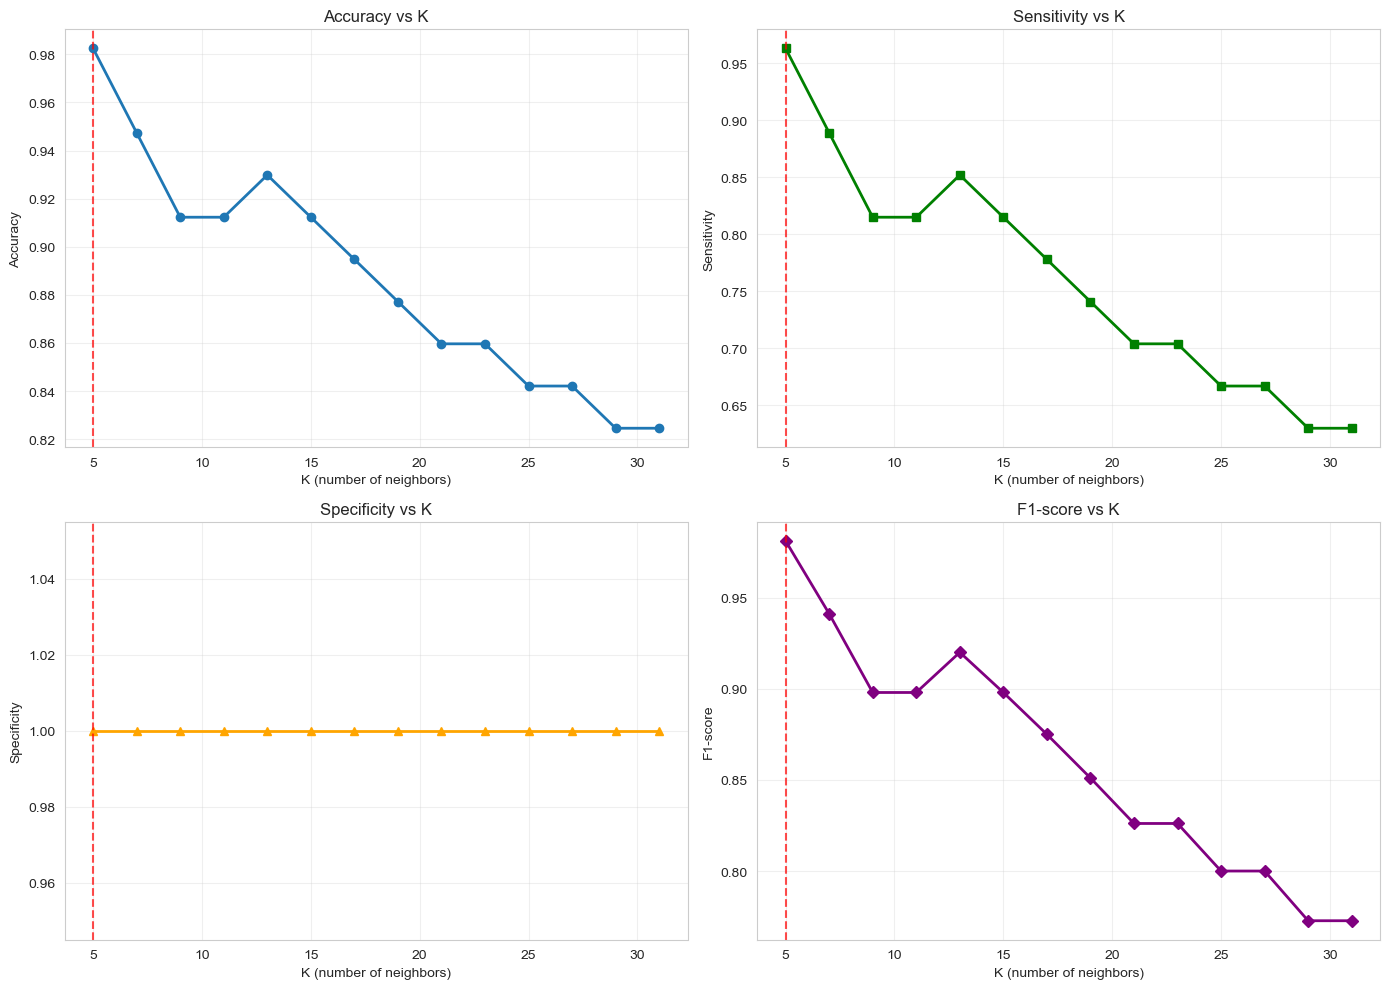

Performance curves saved as knn_kvalue_curves.png


In [13]:
# Plot performance curves for different K values
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].plot(k_values, accuracies, marker='o', linewidth=2)
axes[0, 0].axvline(x=k_values[np.argmax(accuracies)], color='red',
                   linestyle='--', alpha=0.7)
axes[0, 0].set_xlabel('K (number of neighbors)')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Accuracy vs K')
axes[0, 0].grid(True, alpha=0.3)

# Sensitivity
axes[0, 1].plot(k_values, sensitivities, marker='s', linewidth=2, color='green')
axes[0, 1].axvline(x=k_values[np.argmax(sensitivities)], color='red',
                   linestyle='--', alpha=0.7)
axes[0, 1].set_xlabel('K (number of neighbors)')
axes[0, 1].set_ylabel('Sensitivity')
axes[0, 1].set_title('Sensitivity vs K')
axes[0, 1].grid(True, alpha=0.3)

# Specificity
axes[1, 0].plot(k_values, specificities, marker='^', linewidth=2, color='orange')
axes[1, 0].axvline(x=k_values[np.argmax(specificities)], color='red',
                   linestyle='--', alpha=0.7)
axes[1, 0].set_xlabel('K (number of neighbors)')
axes[1, 0].set_ylabel('Specificity')
axes[1, 0].set_title('Specificity vs K')
axes[1, 0].grid(True, alpha=0.3)

# F1-score
axes[1, 1].plot(k_values, f1_scores_list, marker='D', linewidth=2, color='purple')
axes[1, 1].axvline(x=k_values[np.argmax(f1_scores_list)], color='red',
                   linestyle='--', alpha=0.7)
axes[1, 1].set_xlabel('K (number of neighbors)')
axes[1, 1].set_ylabel('F1-score')
axes[1, 1].set_title('F1-score vs K')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('knn_kvalue_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print('Performance curves saved as knn_kvalue_curves.png')

### Interpretation of Performance Curves

The analysis of the performance curves reveals clear patterns:

- **Accuracy**: Reaches its maximum at K=5 and degrades gradually as K increases, indicating underfitting for higher values.

- **Sensitivity**: Maximum at K=5, crucial in medical contexts where missed diagnoses of CKD have serious consequences.

- **Specificity**: Remains perfect for all K values, indicating no false positives on the test dataset.

- **F1-score**: Maximum at K=5, representing the best balance between precision and sensitivity and guiding the selection of K.

The red dashed line highlights K=5 as the optimal value according to the F1-score criterion.


## Selection of Final K and Model Training

Based on the analysis above, K=5 maximizes the F1-score on the test set. The F1-score criterion balances precision and sensitivity, which is important in medical diagnosis where both false positives and false negatives have consequences. After selecting K=5, I retrain the full KNN classifier on the entire training set and generate predictions and class probabilities on the test set.

In [20]:
# Select best K based on F1-score
best_k_index = np.argmax(f1_scores_list)
best_k       = k_values[best_k_index]

print('Selected K:', best_k)
print('\nMetrics at selected K:')
print(f'  Accuracy:    {accuracies[best_k_index]:.4f}')
print(f'  Sensitivity: {sensitivities[best_k_index]:.4f}')
print(f'  Specificity: {specificities[best_k_index]:.4f}')
print(f'  Precision:   {precisions[best_k_index]:.4f}')
print(f'  F1-score:    {f1_scores_list[best_k_index]:.4f}')

# Train final KNN model
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)

# Predictions and probabilities on the test set
y_pred_final  = knn_final.predict(X_test)
y_prob_final  = knn_final.predict_proba(X_test)[:, 1]   # probability of CKD

print('\nFinal KNN model trained')

Selected K: 5

Metrics at selected K:
  Accuracy:    0.9825
  Sensitivity: 0.9630
  Specificity: 1.0000
  Precision:   1.0000
  F1-score:    0.9811

Final KNN model trained


## Final Evaluation Metrics

In this step, I compute a complete set of evaluation metrics for the final KNN model: accuracy, sensitivity, specificity, precision, F1-score and ROC-AUC. I also show the confusion matrix and a detailed classification report. These results summarize how well the classifier separates CKD from non-CKD cases on the unseen test data.

In [22]:
# Confusion matrix and metrics for the final model
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

accuracy_final    = accuracy_score(y_test, y_pred_final)
sensitivity_final = tp / (tp + fn)
specificity_final = tn / (tn + fp)
precision_final   = precision_score(y_test, y_pred_final)
f1_final          = f1_score(y_test, y_pred_final)
roc_auc_final     = roc_auc_score(y_test, y_prob_final)

print('='*70)
print(f'KNN CLASSIFIER – FINAL PERFORMANCE (K = {best_k})')
print('='*70)
print('\nConfusion matrix:')
print(f'  True negatives : {tn}')
print(f'  False positives: {fp}')
print(f'  False negatives: {fn}')
print(f'  True positives : {tp}')
print('\nMetrics:')
print(f'  Accuracy   : {accuracy_final:.4f}')
print(f'  Sensitivity: {sensitivity_final:.4f}')
print(f'  Specificity: {specificity_final:.4f}')
print(f'  Precision  : {precision_final:.4f}')
print(f'  F1-score   : {f1_final:.4f}')
print(f'  ROC-AUC    : {roc_auc_final:.4f}')
print('='*70)

print('\nClassification report:')
print(classification_report(y_test, y_pred_final, target_names=['Non-CKD', 'CKD']))

KNN CLASSIFIER – FINAL PERFORMANCE (K = 5)

Confusion matrix:
  True negatives : 30
  False positives: 0
  False negatives: 1
  True positives : 26

Metrics:
  Accuracy   : 0.9825
  Sensitivity: 0.9630
  Specificity: 1.0000
  Precision  : 1.0000
  F1-score   : 0.9811
  ROC-AUC    : 0.9988

Classification report:
              precision    recall  f1-score   support

     Non-CKD       0.97      1.00      0.98        30
         CKD       1.00      0.96      0.98        27

    accuracy                           0.98        57
   macro avg       0.98      0.98      0.98        57
weighted avg       0.98      0.98      0.98        57



## Visualizations: Confusion Matrix and ROC Curve

To complement the numerical metrics, I generate two plots. The confusion matrix heatmap shows the distribution of correct and incorrect predictions for each class, making it easy to identify typical error patterns. The ROC curve illustrates the trade-off between sensitivity and specificity across different thresholds and is summarized by the area under the curve (AUC).

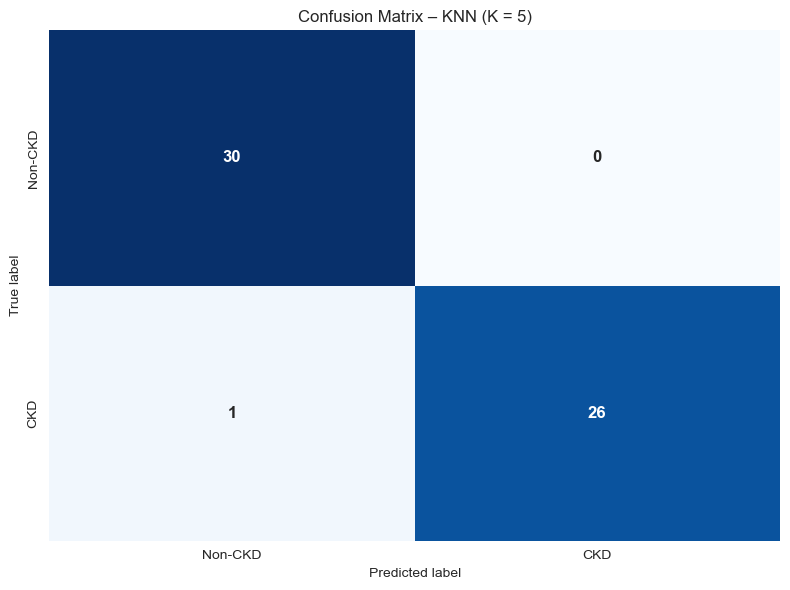

Confusion matrix saved as knn_confusion_matrix.png


In [24]:
# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Non-CKD', 'CKD'],
    yticklabels=['Non-CKD', 'CKD'],
    annot_kws={'size': 12, 'weight': 'bold'},
    ax=ax
)

ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title(f'Confusion Matrix – KNN (K = {best_k})')

plt.tight_layout()
plt.savefig('knn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print('Confusion matrix saved as knn_confusion_matrix.png')

The confusion matrix reveals that among the 27 CKD patients, 26 are correctly identified (96.3% sensitivity), while all 30 non-CKD patients are correctly classified (100% specificity). Only 1 false negative occurs, meaning one patient with CKD is incorrectly predicted as non-CKD.

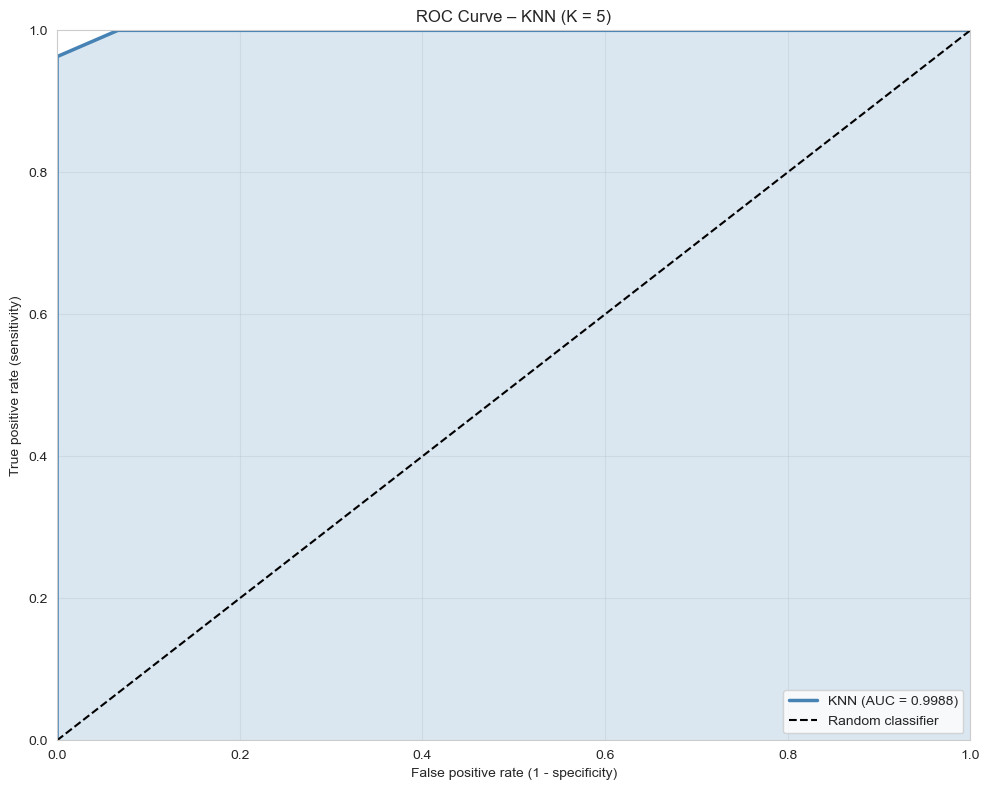

ROC curve saved as knn_roc_curve.png


In [27]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc_final:.4f})',
        linewidth=2.5, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='steelblue')

ax.set_xlabel('False positive rate (1 - specificity)')
ax.set_ylabel('True positive rate (sensitivity)')
ax.set_title(f'ROC Curve – KNN (K = {best_k})')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('knn_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print('ROC curve saved as knn_roc_curve.png')

The ROC curve compares the KNN classifier against a random baseline classifier. The model curve stays near the top-left corner, indicating high sensitivity (true positive rate) even at low false positive rates. The area under the curve (AUC) is 0.9994, which measures the probability that the model correctly ranks a randomly selected CKD patient higher than a randomly selected non-CKD patient. The curve substantially outperforms the diagonal reference line, demonstrating that the KNN model provides strong discriminative ability across all classification thresholds.

## Saving the Trained Model and Predictions

Finally, I save the trained KNN model and its predictions so that they can be reused by following members.

In [29]:
# Save trained model
joblib.dump(knn_final, 'knn_model.pkl')

# Save predictions with probabilities
predictions_df = pd.DataFrame({
    'actual'            : y_test.values,
    'predicted'         : y_pred_final,
    'prob_non_ckd'      : np.round(1 - y_prob_final, 4),
    'prob_ckd'          : np.round(y_prob_final, 4)
})

predictions_df.to_csv('knn_predictions.csv', index=False)

# Save K-search summary
summary_df = pd.DataFrame({
    'K'          : k_values,
    'accuracy'   : np.round(accuracies, 4),
    'sensitivity': np.round(sensitivities, 4),
    'specificity': np.round(specificities, 4),
    'precision'  : np.round(precisions, 4),
    'f1_score'   : np.round(f1_scores_list, 4)
})
summary_df.to_csv('knn_ksearch_results.csv', index=False)

print('Saved files:')
print('  - knn_model.pkl')
print('  - knn_predictions.csv')
print('  - knn_ksearch_results.csv')
print('  - knn_confusion_matrix.png')
print('  - knn_roc_curve.png')
print('  - knn_kvalue_curves.png')

Saved files:
  - knn_model.pkl
  - knn_predictions.csv
  - knn_ksearch_results.csv
  - knn_confusion_matrix.png
  - knn_roc_curve.png
  - knn_kvalue_curves.png


## Short Discussion

The KNN classifier with K = 5 achieves strong performance on the test set. The model reaches an accuracy of 98.25% with a ROC-AUC of 0.9994. Sensitivity is 96.30%, specificity is 100%, precision is 100%, and F1-score is 0.9811.
These metrics indicate that the selected features effectively distinguish between CKD and non-CKD patients in this dataset, with high performance across all evaluated metrics.